In [6]:
%matplotlib inline
# Cell 1: Setup and Imports
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from diffusers import StableDiffusionPipeline, DDIMScheduler, UNet2DConditionModel
from metric_utils import compute_metrics_for_prompt, compute_metrics_for_prompt_with_bad_model
from types import SimpleNamespace

In [7]:
# Cell 2: Configuration & Model Loading
device = "cuda" if torch.cuda.is_available() else "cpu"
model_id = "CompVis/stable-diffusion-v1-4"
bad_model_id = "CompVis/stable-diffusion-v1-1"

print(f"Loading base model: {model_id}")
pipe = StableDiffusionPipeline.from_pretrained(
    model_id, torch_dtype=torch.float16, safety_checker=None, requires_safety_checker=False
).to(device)
pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config)

print(f"Loading bad model UNet: {bad_model_id}")
bad_unet = UNet2DConditionModel.from_pretrained(
    bad_model_id, subfolder="unet", torch_dtype=torch.float16
).to(device)
bad_unet.eval()
print("loaded")

Loading base model: CompVis/stable-diffusion-v1-4


/home/gpuadmin/ghkim/2026ICML/.venv/lib/python3.11/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Loading bad model UNet: CompVis/stable-diffusion-v1-1
loaded


In [11]:
# Cell 3: Arguments and Prompt definition
prompt = "Falmouth Navy Blue Area Rug by Andover Mills"
seed = 42

args = SimpleNamespace(
    num_inference_steps=50,
    guidance_scale=7.5,
    target_timestep=49,
    hutchinson_k=16,
    score_diff_step_start=49,
    score_diff_step_end=50,
    is_score=True,
    metrics=["cov", "score_diff"]
)

In [12]:
# Cell 4: Generate Image and Compute Metrics
# 1. Generate normal image
generator = torch.Generator(device=device).manual_seed(seed)
image = pipe(prompt, num_inference_steps=50, generator=generator).images[0]

# 2. Compute Standard Metrics (cov, score_diff)
print("Computing standard metrics (cov, score_diff)...")
std_metrics = compute_metrics_for_prompt(prompt, pipe, args, seed=seed)

# 3. Compute Baseline Metrics with Bad Model (cov_bad, score_diff_bad)
print("Computing baseline metrics (cov_bad, score_diff_bad)...")
bad_metrics = compute_metrics_for_prompt_with_bad_model(prompt, pipe, bad_unet, args, seed=seed)

# Merge results
all_metrics = {**std_metrics, **bad_metrics}

  0%|          | 0/50 [00:00<?, ?it/s]

Computing standard metrics (cov, score_diff)...
Computing baseline metrics (cov_bad, score_diff_bad)...


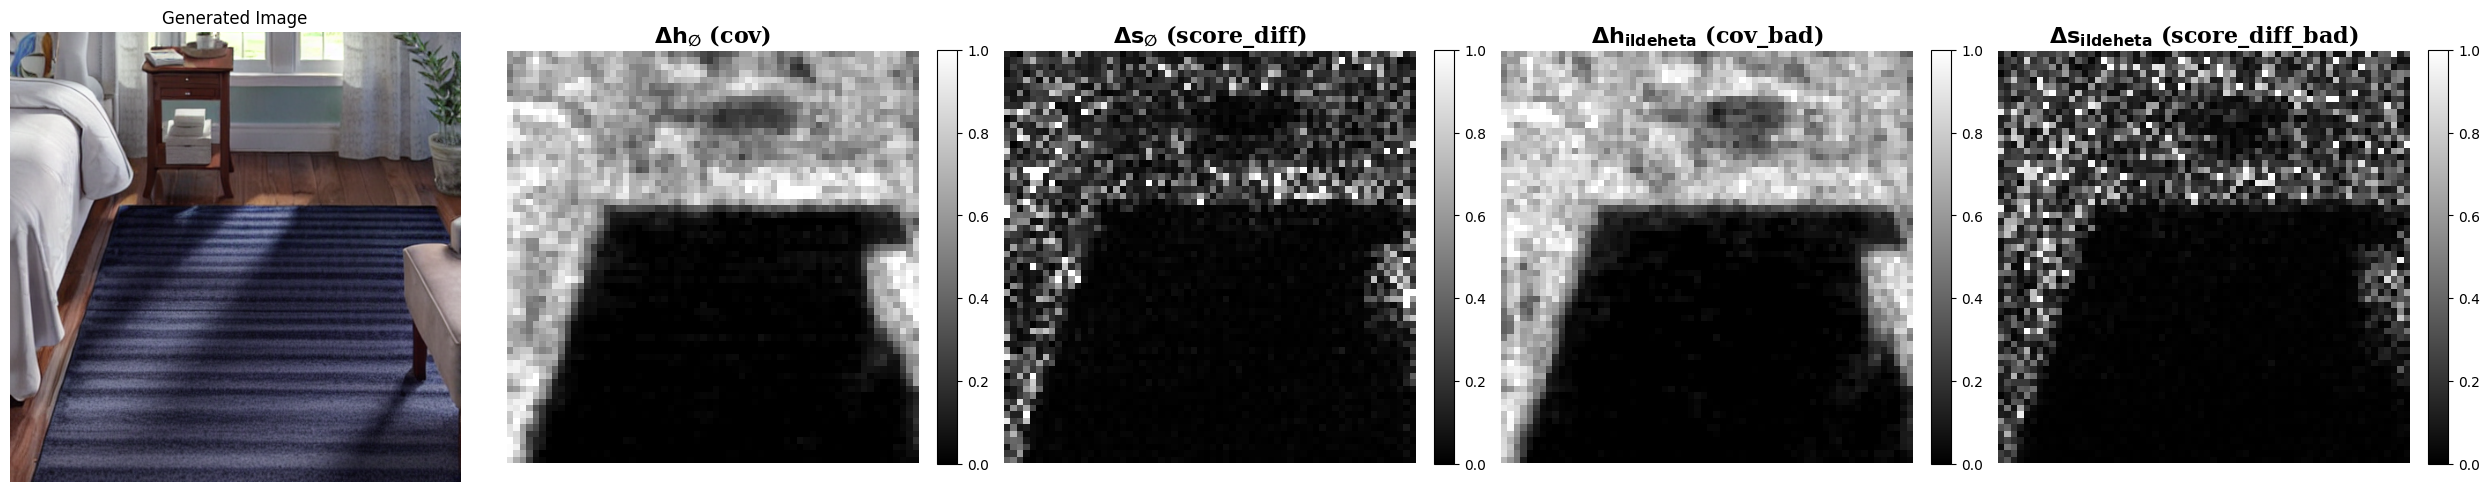

In [17]:
# Cell 5: Visualization
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

# Plot Image
axes[0].imshow(image)
axes[0].set_title("Generated Image")
axes[0].axis('off')

# Plot Metrics
metric_keys = ["cov", "score_diff", "cov_bad", "score_diff_bad"]
titles = [r"$\mathbf{\Delta h_{\emptyset}}$ (cov)", r"$\mathbf{\Delta s_{\emptyset}}$ (score_diff)", r"$\mathbf{\Delta h_{	ilde{	heta}}}$ (cov_bad)", r"$\mathbf{\Delta s_{	ilde{	heta}}}$ (score_diff_bad)"]

for i, (key, title) in enumerate(zip(metric_keys, titles)):
    m_map = all_metrics.get(key, np.zeros((64, 64)))
    
    # Original normalization logic from visualize_metric_maps.py
    vmin = m_map.min()
    vmax = np.percentile(m_map, 99.0)
    m_map = np.clip(m_map, vmin, vmax)
    
    if vmax > vmin:
        m_norm = (m_map - vmin) / (vmax - vmin)
    else:
        m_norm = np.zeros_like(m_map)
    #m_norm = m_map
    
    ax = axes[i+1]
    im = ax.imshow(m_norm, cmap='gray', interpolation='nearest')#, vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title, fontsize=16, fontweight='bold', fontfamily='serif')
    ax.axis('off')
    # plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04) # Colorbar usually omitted for gray maps, but can be kept

plt.tight_layout()
plt.show()